# 10. Putting It All Together
---
Let's apply everything from this course to train a real neural network on the **MNIST handwritten digits dataset**.

We'll use **PyTorch** — the most popular deep learning framework — which handles backprop automatically via **autograd**.


## 10.1 Why PyTorch?

Writing backprop by hand (as we did in Notebook 7) is great for learning. In practice, frameworks like **PyTorch** and **TensorFlow** compute gradients **automatically**.

```python
# PyTorch autograd in 3 lines
z = w * x + b        # define computation
loss = (z - y)**2    # define loss
loss.backward()      # ← backprop done automatically!
# w.grad, b.grad now contain ∂loss/∂w, ∂loss/∂b
```

You focus on the **architecture**. The framework handles the gradients.


In [1]:
# Check if PyTorch is available, install if not
try:
    import torch
    print(f"PyTorch version: {torch.__version__}")
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "torch", "torchvision", "--break-system-packages", "-q"])
    import torch
    print(f"PyTorch installed: {torch.__version__}")


PyTorch version: 2.11.0


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# ── Load MNIST ──
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_data = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_data  = datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False)

print(f"Training samples: {len(train_data)}")
print(f"Test samples:     {len(test_data)}")
print(f"Image shape:      {train_data[0][0].shape}  (1 channel × 28×28 pixels)")
print(f"Classes:          {train_data.classes}")


100%|██████████████████████████████████████| 9.91M/9.91M [00:11<00:00, 880kB/s]
100%|██████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 181kB/s]
100%|██████████████████████████████████████| 1.65M/1.65M [00:02<00:00, 758kB/s]
100%|██████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 429kB/s]

Training samples: 60000
Test samples:     10000
Image shape:      torch.Size([1, 28, 28])  (1 channel × 28×28 pixels)
Classes:          ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


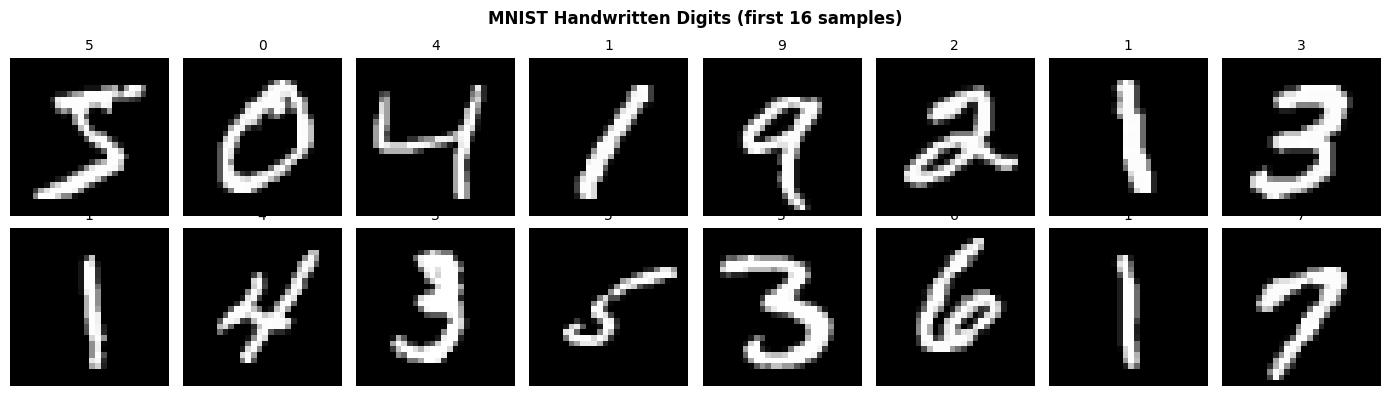

In [3]:
# Visualize some MNIST samples
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    img, label = train_data[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(str(label), fontsize=10)
    ax.axis('off')
plt.suptitle("MNIST Handwritten Digits (first 16 samples)", fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


## 10.2 Define the Network

We'll build an MLP:
```
Input: 28×28 = 784 pixels
  ↓ Flatten
  ↓ Linear(784 → 256) → ReLU → BatchNorm
  ↓ Dropout(0.3)
  ↓ Linear(256 → 128) → ReLU → BatchNorm
  ↓ Dropout(0.3)  
  ↓ Linear(128 → 10)  → (Softmax handled in loss)
Output: 10 class probabilities
```


In [4]:
class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),                     # 28×28 → 784

            nn.Linear(784, 256),              # Layer 1
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),

            nn.Linear(256, 128),              # Layer 2
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),

            nn.Linear(128, 10),               # Output: 10 classes
        )

    def forward(self, x):
        return self.network(x)

model = MNISTClassifier()
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")


MNISTClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): ReLU()
    (7): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total parameters: 235,914


## 10.3 Define Loss & Optimizer

- **Loss:** CrossEntropyLoss (= softmax + categorical cross-entropy combined)
- **Optimizer:** Adam with lr=0.001


In [5]:
criterion = nn.CrossEntropyLoss()   # handles softmax internally
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss function: CrossEntropyLoss")
print("Optimizer:     Adam (lr=0.001)")


Loss function: CrossEntropyLoss
Optimizer:     Adam (lr=0.001)


## 10.4 Training Loop

This is the full training loop — forward pass, loss, backprop, update:

```python
for each batch:
    1. Forward:   predictions = model(X)
    2. Loss:      loss = criterion(predictions, labels)
    3. Zero grad: optimizer.zero_grad()
    4. Backward:  loss.backward()          ← autograd does backprop!
    5. Update:    optimizer.step()         ← updates all weights
```


In [6]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()   # enable dropout + batchnorm training mode
    total_loss, correct = 0, 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()           # reset gradients
        logits = model(X_batch)         # forward pass
        loss = criterion(logits, y_batch)  # compute loss
        loss.backward()                 # backprop (autograd)
        optimizer.step()                # update weights
        total_loss += loss.item()
        correct += (logits.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def evaluate(model, loader, criterion):
    model.eval()    # disable dropout + batchnorm eval mode
    total_loss, correct = 0, 0
    with torch.no_grad():   # no gradient computation during eval
        for X_batch, y_batch in loader:
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item()
            correct += (logits.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

# ── Train for 5 epochs ──
N_EPOCHS = 5
train_losses, test_losses = [], []
train_accs, test_accs     = [], []

print(f"{'Epoch':>6} {'Train Loss':>12} {'Train Acc':>11} {'Test Loss':>11} {'Test Acc':>10}")
print("-" * 55)

for epoch in range(1, N_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
    te_loss, te_acc = evaluate(model, test_loader, criterion)
    train_losses.append(tr_loss); test_losses.append(te_loss)
    train_accs.append(tr_acc);   test_accs.append(te_acc)
    print(f"{epoch:>6} {tr_loss:>12.4f} {tr_acc:>10.2%} {te_loss:>11.4f} {te_acc:>10.2%}")


 Epoch   Train Loss   Train Acc   Test Loss   Test Acc
-------------------------------------------------------
     1       0.2903     91.35%      0.1201     96.25%
     2       0.1706     94.75%      0.1237     96.88%
     3       0.1447     95.56%      0.1250     97.12%
     4       0.1268     96.07%      0.0939     97.24%
     5       0.1173     96.39%      0.0931     97.46%


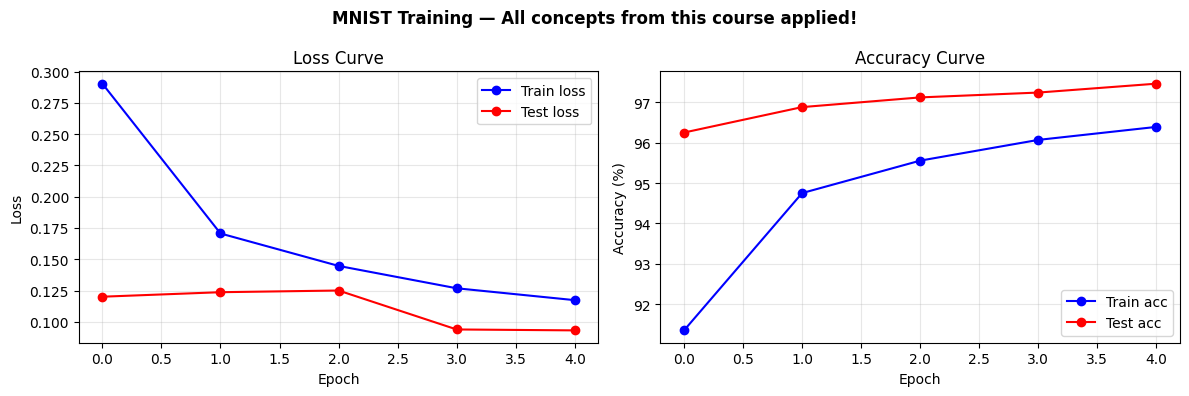

In [7]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, 'b-o', label='Train loss')
axes[0].plot(test_losses,  'r-o', label='Test loss')
axes[0].set_title("Loss Curve"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot([a*100 for a in train_accs], 'b-o', label='Train acc')
axes[1].plot([a*100 for a in test_accs],  'r-o', label='Test acc')
axes[1].set_title("Accuracy Curve"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("MNIST Training — All concepts from this course applied!", fontweight='bold')
plt.tight_layout(); plt.show()


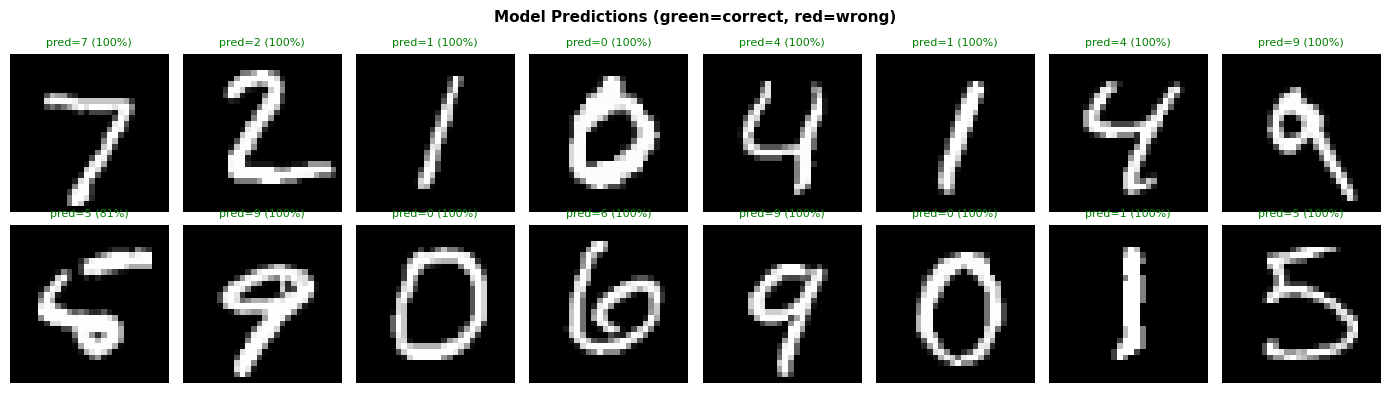

In [9]:
# Visualize predictions on test samples
model.eval()
X_sample, y_sample = next(iter(test_loader))

with torch.no_grad():
    logits = model(X_sample[:16])
    probs  = torch.softmax(logits, dim=1)
    preds  = logits.argmax(1)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    img = X_sample[i].squeeze().numpy()
    ax.imshow(img, cmap='gray')
    pred, true = preds[i].item(), y_sample[i].item()
    conf = probs[i, pred].item()
    color = 'green' if pred == true else 'red'
    ax.set_title(f"pred={pred} ({conf:.0%})", color=color, fontsize=8)
    ax.axis('off')

plt.suptitle("Model Predictions (green=correct, red=wrong)", fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()


## 10.5 Reading a Loss Curve

| Pattern | What It Means |
|---|---|
| Both losses decrease together | ✅ Good training |
| Train loss decreases, test loss increases | ❌ Overfitting — try dropout, more data, L2 |
| Both losses plateau high | ❌ Underfitting — try deeper/wider network, more epochs |
| Loss spikes or diverges | ❌ Learning rate too high, try reducing it |
| Loss decreases then flatlines | Possible local minimum; try different init or optimizer |


## ✏️ Final Exercises

1. **Improve the model:** Add another hidden layer and/or increase the number of neurons. Can you reach >98% test accuracy?
2. **Diagnose overfitting:** Remove all Dropout layers. Train for 10 epochs. What happens to train vs test accuracy?
3. **Try different optimizers:** Replace Adam with `optim.SGD(lr=0.01, momentum=0.9)`. Compare the learning curves.